In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
df_car = pd.read_csv("Car or van.csv")
df_age = pd.read_csv("age.csv")
df_distance_travelled = pd.read_csv("Distance_travelled_to _work.csv")
df_economic_act = pd.read_csv("economic activity.csv")

## Data Cleaning & Feature Selection
### Car or Van Availability

In [3]:
df_car.head(5)

,date,geography,geography code,Rural Urban,Cars: All categories: Car or van availability; measures: Value,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Cars: sum of All cars or vans in the area; measures: Value
0,2011,Darlington,E06000005,Total,46670,13052,20682,10450,1962,524,49794
1,2011,County Durham,E06000047,Total,223803,60926,96086,52740,10775,3276,248586
2,2011,Hartlepool,E06000001,Total,40434,14268,16573,7662,1535,396,38269
3,2011,Middlesbrough,E06000002,Total,57203,21488,22963,10207,1945,600,51821
4,2011,Northumberland,E06000057,Total,138534,30543,60875,36916,7671,2529,168974


In [4]:
df_car.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 11 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   date                                                            174 non-null    int64
 1   geography                                                       174 non-null    str  
 2   geography code                                                  174 non-null    str  
 3   Rural Urban                                                     174 non-null    str  
 4   Cars: All categories: Car or van availability; measures: Value  174 non-null    int64
 5   Cars: No cars or vans in household; measures: Value             174 non-null    int64
 6   Cars: 1 car or van in household; measures: Value                174 non-null    int64
 7   Cars: 2 cars or vans in household; measures: Value              174 non-null    in

In [5]:
df_car.isna().sum()

date                                                              0
geography                                                         0
geography code                                                    0
Rural Urban                                                       0
Cars: All categories: Car or van availability; measures: Value    0
Cars: No cars or vans in household; measures: Value               0
Cars: 1 car or van in household; measures: Value                  0
Cars: 2 cars or vans in household; measures: Value                0
Cars: 3 cars or vans in household; measures: Value                0
Cars: 4 or more cars or vans in household; measures: Value        0
Cars: sum of All cars or vans in the area; measures: Value        0
dtype: int64

In [6]:
df_car.shape

(174, 11)

In [7]:
df_car = df_car.drop(["date", "Cars: All categories: Car or van availability; measures: Value", "Cars: sum of All cars or vans in the area; measures: Value"], axis = 1)

In [8]:
df_car.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,13052,20682,10450,1962,524
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529


In [9]:
df_car_cp = df_car.copy()

In [10]:
numeric_columns = df_car_cp.select_dtypes(include = "number").columns

In [11]:
df_car_cp[numeric_columns] = df_car_cp[numeric_columns].div(df_car_cp[numeric_columns].sum(axis =1), axis =0)

In [12]:
df_car_cp.head(4)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,0.279666,0.443154,0.223913,0.042040,0.011228
1,County Durham,E06000047,Total,0.272230,0.429333,0.235654,0.048145,0.014638
2,Hartlepool,E06000001,Total,0.352871,0.409878,0.189494,0.037963,0.009794
3,Middlesbrough,E06000002,Total,0.375645,0.401430,0.178435,0.034002,0.010489


### Age

In [13]:
df_age.head(5)

,date,geography,geography code,Rural Urban,Age: All usual residents; measures: Value,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,...,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value,Age: Mean Age; measures: Value,Age: Median Age; measures: Value
0,2011,Darlington,E06000005,Total,105564,6579,3790,2284,6224,1330,...,6607,20917,21560,6685,9717,6172,1740,810,40.2,41.0
1,2011,County Durham,E06000047,Total,513242,28574,15818,9841,27869,5882,...,30628,96150,108200,35395,50883,30635,7321,3506,41.0,42.0
2,2011,Hartlepool,E06000001,Total,92028,5698,3202,1990,5653,1257,...,5622,16869,19326,5837,8174,5568,1323,533,39.8,40.0
3,2011,Middlesbrough,E06000002,Total,138412,9431,5178,3098,8485,1811,...,9765,25414,27065,7531,10833,7393,1658,807,37.8,37.0
4,2011,Northumberland,E06000057,Total,316028,16003,9863,6482,17677,3841,...,16187,56156,71135,24533,34366,21018,5233,2687,42.8,45.0


In [14]:
df_age.shape

(174, 23)

In [15]:
df_age.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   date                                       174 non-null    int64  
 1   geography                                  174 non-null    str    
 2   geography code                             174 non-null    str    
 3   Rural Urban                                174 non-null    str    
 4   Age: All usual residents; measures: Value  174 non-null    int64  
 5   Age: Age 0 to 4; measures: Value           174 non-null    int64  
 6   Age: Age 5 to 7; measures: Value           174 non-null    int64  
 7   Age: Age 8 to 9; measures: Value           174 non-null    int64  
 8   Age: Age 10 to 14; measures: Value         174 non-null    int64  
 9   Age: Age 15; measures: Value               174 non-null    int64  
 10  Age: Age 16 to 17; measures: Value   

In [16]:
df_age = df_age.drop(["date", "Age: All usual residents; measures: Value","Age: Mean Age; measures: Value", "Age: Median Age; measures: Value" ], axis = 1)

In [17]:
df_age.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,6579,3790,2284,6224,1330,2721,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,28574,15818,9841,27869,5882,12107,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,5698,3202,1990,5653,1257,2570,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,9431,5178,3098,8485,1811,3747,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,16003,9863,6482,17677,3841,7631,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [18]:
df_age_cp = df_age.copy()

In [19]:
numeric_columns = df_age_cp.select_dtypes(include="number").columns

In [20]:
df_age_cp[numeric_columns] = df_age_cp[numeric_columns].div(df_age_cp[numeric_columns].sum(axis =1), axis=0)

In [21]:
df_age_cp.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,0.062322,0.035902,0.021636,0.058959,0.012599,0.025776,0.022328,0.057510,0.062588,0.198145,0.204236,0.063327,0.092048,0.058467,0.016483,0.007673
1,County Durham,E06000047,Total,0.055674,0.030820,0.019174,0.054300,0.011460,0.023589,0.029768,0.068496,0.059676,0.187339,0.210817,0.068964,0.099140,0.059689,0.014264,0.006831
2,Hartlepool,E06000001,Total,0.061916,0.034794,0.021624,0.061427,0.013659,0.027926,0.026633,0.064709,0.061090,0.183303,0.210001,0.063426,0.088821,0.060503,0.014376,0.005792
3,Middlesbrough,E06000002,Total,0.068137,0.037410,0.022382,0.061302,0.013084,0.027071,0.032555,0.084458,0.070550,0.183611,0.195539,0.054410,0.078266,0.053413,0.011979,0.005830
4,Northumberland,E06000057,Total,0.050638,0.031209,0.020511,0.055935,0.012154,0.024147,0.022125,0.051337,0.051220,0.177693,0.225091,0.077629,0.108744,0.066507,0.016559,0.008502


### Distance Travelled To work

In [22]:
df_distance_travelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 17 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   date                                                                                     174 non-null    int64  
 1   geography                                                                                174 non-null    str    
 2   geography code                                                                           174 non-null    str    
 3   Rural Urban                                                                              174 non-null    str    
 4   Distance travelled to work: All categories: Distance travelled to work; measures: Value  174 non-null    int64  
 5   Distance travelled to work: Less than 2km; measures: Value                 

In [23]:
df_distance_travelled.shape

(174, 17)

In [24]:
df_distance_travelled.isna().sum()

date                                                                                       0
geography                                                                                  0
geography code                                                                             0
Rural Urban                                                                                0
Distance travelled to work: All categories: Distance travelled to work; measures: Value    0
Distance travelled to work: Less than 2km; measures: Value                                 0
Distance travelled to work: 2km to less than 5km; measures: Value                          0
Distance travelled to work: 5km to less than 10km; measures: Value                         0
Distance travelled to work: 10km to less than 20km; measures: Value                        0
Distance travelled to work: 20km to less than 30km; measures: Value                        0
Distance travelled to work: 30km to less than 40km; measures: Value   

In [25]:
df_distance_travelled = df_distance_travelled.drop(["date", "Distance travelled to work: All categories: Distance travelled to work; measures: Value","Distance travelled to work: Total distance (km); measures: Value", "Distance travelled to work: Average distance (km); measures: Value"], axis = 1)

In [26]:
df_distance_travelled.head(5)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,11433,12516,4226,5552,4410,793,1234,1502,4180,3168
1,County Durham,E06000047,Total,36588,31877,38010,51191,19810,6846,2222,5704,20652,14994
2,Hartlepool,E06000001,Total,8452,10557,3406,5707,1684,681,489,1154,2473,3164
3,Middlesbrough,E06000002,Total,10393,15799,11414,4137,1281,642,848,1733,3337,4963
4,Northumberland,E06000057,Total,25944,14491,19568,30255,12969,5666,4162,5593,17894,10359


In [27]:
df_dist_cp = df_distance_travelled.copy()
numeric_columns = df_dist_cp.select_dtypes(include="number").columns
df_dist_cp[numeric_columns] = df_dist_cp[numeric_columns].div(df_dist_cp[numeric_columns].sum(axis =1), axis=0)


In [28]:
df_dist_cp.head(4)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,0.233260,0.255356,0.086220,0.113274,0.089974,0.016179,0.025176,0.030644,0.085282,0.064635
1,County Durham,E06000047,Total,0.160548,0.139876,0.166788,0.224626,0.086926,0.030040,0.009750,0.025029,0.090621,0.065794
2,Hartlepool,E06000001,Total,0.223793,0.279530,0.090185,0.151111,0.044589,0.018032,0.012948,0.030556,0.065480,0.083777
3,Middlesbrough,E06000002,Total,0.190533,0.289640,0.209251,0.075843,0.023484,0.011770,0.015546,0.031771,0.061177,0.090986


### Economic Activity

In [29]:
df_economic_act.head(5)

,date,geography,geography code,Rural Urban,Economic Activity: All categories: Economic activity; measures: Value,Economic Activity: Economically active: Total; measures: Value,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Total; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,2011,Darlington,E06000005,Total,76635,53443,11555,30337,234,1254,1289,2818,4002,1954,23192,12214,2742,3081,3737,1418
1,2011,County Durham,E06000047,Total,383796,247101,50595,143922,1052,5717,5799,12741,17013,10262,136695,65444,23837,14190,24887,8337
2,2011,Hartlepool,E06000001,Total,66804,43513,10092,22635,212,846,892,1855,5194,1787,23291,10621,3042,3265,4733,1630
3,2011,Middlesbrough,E06000002,Total,100551,63582,15063,31301,300,1068,1331,2472,7631,4416,36969,13922,7453,5569,6841,3184
4,2011,Northumberland,E06000057,Total,233224,158268,34368,86380,993,5351,5151,10568,10329,5128,74956,43897,8108,8368,10321,4262


In [30]:
df_economic_act.shape

(174, 20)

In [31]:
df_economic_act.isna().sum()

date                                                                                                   0
geography                                                                                              0
geography code                                                                                         0
Rural Urban                                                                                            0
Economic Activity: All categories: Economic activity; measures: Value                                  0
Economic Activity: Economically active: Total; measures: Value                                         0
Economic Activity: Economically active: Employee: Part-time; measures: Value                           0
Economic Activity: Economically active: Employee: Full-time; measures: Value                           0
Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value       0
Economic Activity: Economically active: Self-employed w

In [32]:
df_economic_act = df_economic_act.drop(["date", "Economic Activity: All categories: Economic activity; measures: Value", "Economic Activity: Economically active: Total; measures: Value", "Economic Activity: Economically inactive: Total; measures: Value"], axis = 1)

In [33]:
df_economic_act.head(4)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,11555,30337,234,1254,1289,2818,4002,1954,12214,2742,3081,3737,1418
1,County Durham,E06000047,Total,50595,143922,1052,5717,5799,12741,17013,10262,65444,23837,14190,24887,8337
2,Hartlepool,E06000001,Total,10092,22635,212,846,892,1855,5194,1787,10621,3042,3265,4733,1630
3,Middlesbrough,E06000002,Total,15063,31301,300,1068,1331,2472,7631,4416,13922,7453,5569,6841,3184


In [34]:
df_eco_cp = df_economic_act.copy()
numeric_columns = df_eco_cp.select_dtypes(include="number").columns
df_eco_cp[numeric_columns] = df_eco_cp[numeric_columns].div(df_eco_cp[numeric_columns].sum(axis =1), axis=0)


### Merging Columns

In [36]:
df_age_merge = df_age.drop(["geography", "Rural Urban"], axis = 1)
df_distance_travelled_merge = df_distance_travelled.drop(["geography", "Rural Urban"], axis = 1)
df_economic_act_merg =  df_economic_act.drop(["geography", "Rural Urban"], axis = 1)


In [37]:
df_age_merge_cp = df_age_cp.drop(["geography", "Rural Urban"], axis = 1)
df_distance_travelled_merge_cp = df_dist_cp.drop(["geography", "Rural Urban"], axis = 1)
df_economic_act_merg_cp =  df_eco_cp.drop(["geography", "Rural Urban"], axis = 1)

In [38]:
merged_df = df_car.merge(df_distance_travelled_merge, on = "geography code", how = "inner").merge(df_economic_act_merg, on = "geography code", how = "inner").merge(df_age_merge, on = "geography code", how = "inner")

In [39]:
merged_df_cp = df_car_cp.merge(df_distance_travelled_merge_cp, on = "geography code", how = "inner").merge(df_economic_act_merg_cp, on = "geography code", how = "inner").merge(df_age_merge_cp, on = "geography code", how = "inner")

In [43]:
final_df = merged_df.iloc[:, 3:]

In [44]:
final_df_cp = merged_df_cp.iloc[:, 3:]

### Plotting
#### PCA


In [47]:
scalar = StandardScaler()

In [48]:
scaled_data = scalar.fit_transform(final_df_cp)

In [49]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

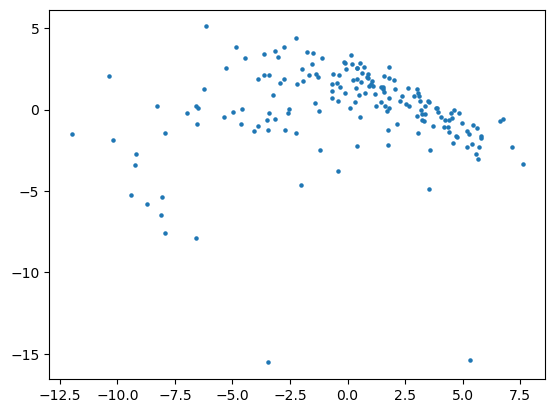

In [51]:
plt.scatter(pca_result[:,0], pca_result[:,1], s = 5)

#### t-SNE

In [52]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 1729) 
tsne_result = tsne.fit_transform(scaled_data)

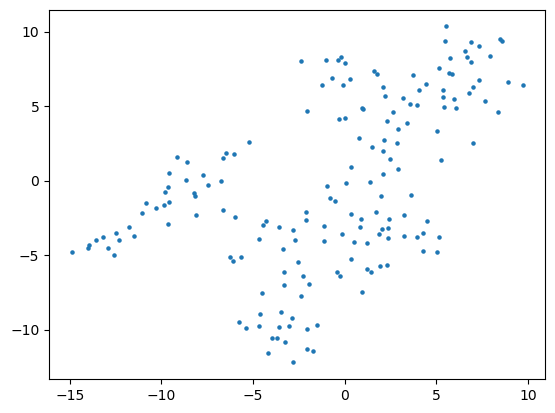

In [54]:
plt.scatter(tsne_result[:,0], tsne_result[:,1], s=5)

#### PCA = 25 comp.

In [55]:
pca = PCA(n_components=25)
pca_res = pca.fit_transform(scaled_data)

#### t-SNE

In [56]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 1729) 
tsne_result = tsne.fit_transform(pca_res)

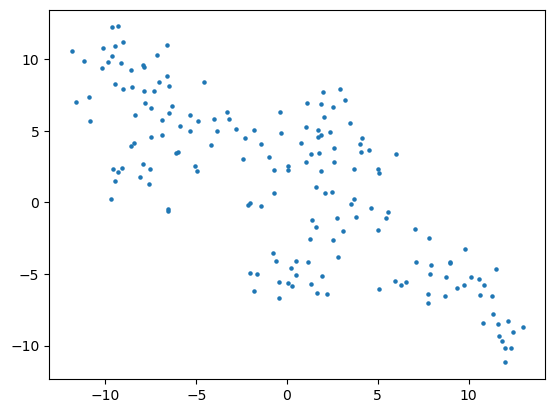

In [57]:
plt.scatter(tsne_result[:,0], tsne_result[:,1], s=5)

#### UMAP

c:\Users\Aman Kumar Singh\anaconda3\envs\text_analytics\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


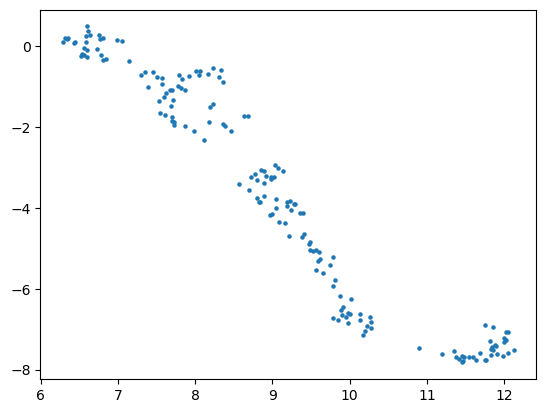

In [58]:
from umap.umap_ import UMAP
umap = UMAP(n_components=5,min_dist=0.01, random_state=400)
embedding = umap.fit_transform(scaled_data)
plt.scatter(embedding[:,0], embedding[:,1], s=5)

In [60]:
import seaborn as sns

<Axes: xlabel='Col1', ylabel='Col2'>

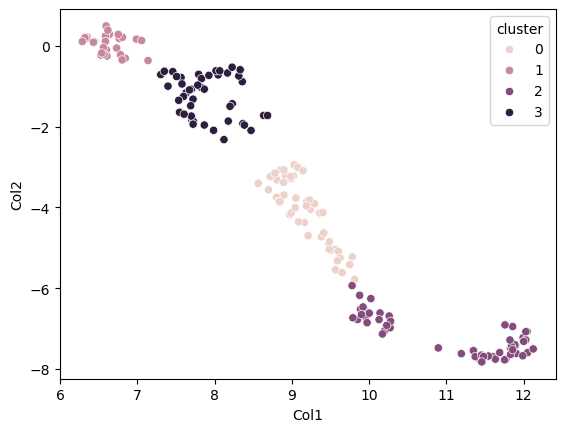

In [61]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=4, random_state=1429)
cluster_label = kmean.fit_predict(embedding)
embedds = pd.DataFrame({"Col1": embedding[:,0], "Col2" : embedding[:,1], "cluster": cluster_label})
sns.scatterplot(data = embedds, x = "Col1", y = "Col2", hue = "cluster")

In [62]:
cluster_label

array([3, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 3, 3, 0, 3, 1, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 3, 0, 2, 0, 0, 0, 1, 2, 0, 3, 2, 1, 0, 0, 0,
       2, 0, 0, 0, 2, 0, 0, 2, 2, 1, 3, 3, 1, 3, 3, 1, 1, 0, 3, 3, 3, 0,
       2, 0, 0, 3, 0, 0, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 1, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2,
       2, 2, 2, 2, 2, 2, 2, 3, 2, 1, 3, 3, 2, 2, 2, 2, 3, 3, 3, 3, 1, 3,
       3, 3, 3, 3, 3, 2, 2, 1, 1, 1, 2, 3, 3, 3, 1, 3, 1, 1, 3, 1, 1, 1,
       1, 1, 3, 3, 1, 1, 1, 1, 2, 0, 0, 3, 2, 0, 0, 0, 0, 0, 1, 0],
      dtype=int32)

In [63]:
embedds = pd.DataFrame({"Col1": embedding[:,0], "Col2" : embedding[:,1], "cluster": cluster_label})

In [64]:
import seaborn as sns

<Axes: xlabel='Col1', ylabel='Col2'>

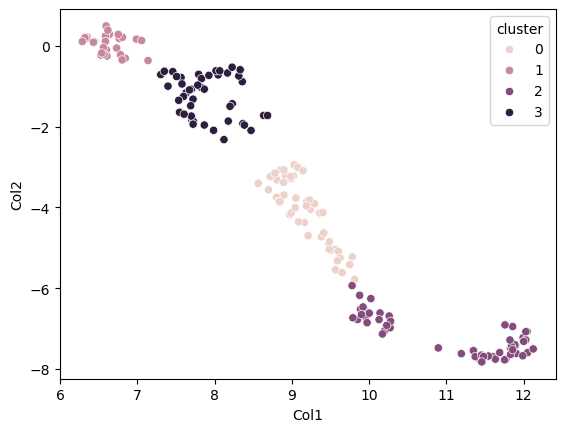

In [65]:
sns.scatterplot(data = embedds, x = "Col1", y = "Col2", hue = "cluster")

#### Merged Data

In [77]:
merged_data = pd.read_csv("merged_data.csv")

In [80]:
merged_data.columns = ['Unnamed: 0',
 'geography',
 'geography code',
 'Rural Urban',
 'No Cars and Vans',
 '1 Car or Van',
 '(2, 3, 4) Car or Van',
 'Young 0-19',
 'Working-age 20-64',
 'Retired-age 65-90',
 'Distance (Work from home)',
 'Distance < 10 km',
 '10 km < Distance < 30 km',
 '30 km < Distanc < 60 km',
 'Unemployed',
 'Economically active',
 'Economically Inactive']

In [82]:
merged_data["cluster"] = cluster_label

In [86]:
merged_data["P1"] = embedding[:,0]
merged_data["P2"] = embedding[:,1]

In [88]:
pf = merged_data.drop(["Unnamed: 0", "geography", "Rural Urban"], axis =1)

In [90]:
cleaned_df = merged_data.merge(pf, on="geography code", how = "inner")

In [92]:
merged_data.iloc[:, 4:].groupby("cluster").mean()

,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,P1,P2
cluster,,,,,,,,,,,,,,,
0,29241.000000,42747.306122,28062.469388,60125.693878,140941.530612,38745.061224,8152.897959,62007.489796,21316.367347,6066.632653,9664.591837,106820.408163,57652.204082,9.186245,-4.124742
1,23929.000000,56810.444444,48837.777778,65426.037037,168922.777778,64769.481481,19676.037037,63546.518519,31566.074074,13575.333333,7464.000000,141436.185185,68385.000000,6.639686,0.037107
2,43450.566038,46529.735849,22568.207547,67363.660377,174565.528302,33465.377358,11444.830189,76473.301887,23977.283019,6059.150943,10629.641509,132896.886792,62900.622642,11.082531,-7.185882
3,35733.288889,83712.577778,80551.911111,114390.822222,282295.400000,84491.644444,26370.866667,112072.044444,54021.600000,25202.666667,12468.266667,239196.022222,99146.333333,7.896764,-1.252005


<Axes: ylabel='cluster'>

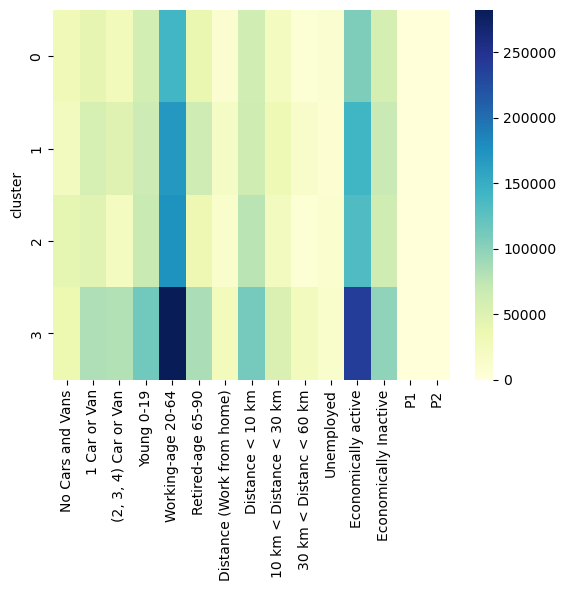

In [93]:
sns.heatmap(merged_data.iloc[:, 4:].groupby("cluster").mean(), annot=False, fmt=".0f", cmap='YlGnBu')

#### Data

In [287]:
cleaned_df.to_csv("Data.csv")


#### Data Cleaning for 2011 Vs 2021

In [122]:
df11 = pd.read_csv("bulk (2).csv")

In [2]:
tempo_df = pd.read_csv("Chart2.csv")

In [3]:
df21 = pd.read_csv("census2021-ts007-utla (Age).csv")

In [4]:
df21 = df21.drop(["Age: Aged 4 years and under; measures: Value",
                  "Age: Aged 5 to 9 years; measures: Value", 
                  "Age: Aged 10 to 15 years; measures: Value", 
                  "Age: Aged 16 to 19 years; measures: Value", 
                  "Age: Aged 20 to 24 years; measures: Value",
                  "Age: Aged 25 to 34 years; measures: Value",
                  "Age: Aged 35 to 49 years; measures: Value",
                  "Age: Aged 50 to 64 years; measures: Value",
                  "Age: Aged 65 to 74 years; measures: Value",
                  "Age: Aged 75 to 84 years; measures: Value",
                  "Age: Aged 50 to 64 years; measures: Value",
                  "Age: Aged 85 years and over; measures: Value",
                  "date",
                  "Age: Total; measures: Value"], axis =1)

In [5]:
df21.columns = ["geography", 'geography code'] + [str(i) for i in range(0,100)] + ["100+"]

In [6]:
df21.head(5)

,geography,geography code,0,1,2,3,4,5,6,7,...,91,92,93,94,95,96,97,98,99,100+
0,Darlington,E06000005,1040,1048,1109,1167,1130,1220,1229,1257,...,178,137,105,104,73,53,20,38,25,22
1,County Durham,E06000047,4623,4809,4969,4990,5361,5534,5468,5650,...,834,633,446,369,284,235,127,92,62,87
2,Hartlepool,E06000001,918,954,1046,988,1077,1109,1032,1097,...,130,110,92,62,48,30,19,19,14,21
3,Middlesbrough,E06000002,1621,1720,1766,1908,1913,1861,1920,1950,...,217,153,112,82,61,47,38,18,15,22
4,Northumberland,E06000057,2575,2631,2905,2985,3139,3231,3191,3280,...,611,514,383,316,219,177,114,67,49,80


In [8]:
df21_bands = df21[[	"geography", "geography code"]]

In [9]:
df21_bands["0--19"] = df21.iloc[:, 2:22].sum(axis = 1)
df21_bands["20--64"] = df21.iloc[:, 22:67].sum(axis =1)
df21_bands["65--"] = df21.iloc[:, 67:].sum(axis =1)





In [12]:
codes_2011 = set(tempo_df['geography'])
codes_2021 = set(df21_bands['geography'])

# In 2011 but NOT in 2021
missing_in_2021 = codes_2011 - codes_2021

# In 2021 but NOT in 2011
missing_in_2011 = codes_2021 - codes_2011

print("Missing in 2021:", missing_in_2021)
print("Missing in 2011:", missing_in_2011)

Missing in 2021: set()
Missing in 2011: set()


In [13]:
merged = tempo_df.merge(
    df21_bands,
    on='geography code',
    how='outer',
    indicator=True
)

only_2011 = merged[merged['_merge'] == 'left_only']['geography code']
only_2021 = merged[merged['_merge'] == 'right_only']['geography code']

print("Only in 2011:\n", only_2011.tolist())
print("\nOnly in 2021:\n", only_2021.tolist())

Only in 2011:
 ['E06000029', 'E10000002', 'E10000009', 'E10000021']

Only in 2021:
 ['E06000058']


In [30]:
data11_21 = tempo_df.merge(df21_bands, on = "geography", how = "inner") 

In [32]:
data11_21 = data11_21[["geography code_x", "geography", "Young 0-19", "Working-age 20-64", "Retired-age 65-90", "0--19",
 "20--64",
 "65--"]]

In [33]:
mk = pd.read_csv("Cleaned_Data\Data.csv")

In [34]:
mk = mk[["geography", "cluster"]]

In [37]:
Data11_21 = data11_21.merge(mk, on = "geography", how = "inner")

In [39]:
Data11_21.to_csv("Data21-11.csv")

In [20]:
mk = mk[["geography", "cluster"]]

In [21]:
cd = pd.read_csv("Data11_21.csv")

In [23]:
Data11_21 = cd.merge(mk, on = "geography", how = "inner")

In [28]:
Data11_21.to_csv("Data11_21.csv")